# Part 1: Data Preprocessing & Feature Engineering 

- In this section, the cleaned NYC taxi dataset from Assignment 1 is prepared for machine learning. New temporal, trip, and fare-based features are created to capture when trips occur, their characteristics, and cost structure. Pickup and dropoff boroughs are obtained using the taxi zone lookup table and encoded for use in machine learning models.

- Two target variables are created: `tip_amount` for the regression task and `high_tip`, a binary variable indicating whether the tip exceeds 20% of the fare amount for the classification task.

- Finally, the dataset is split into training (70%), validation (15%), and test (15%) sets using stratified sampling based on `high_tip`. Numeric features are scaled using `StandardScaler`, fitted only on the training data to prevent data leakage, and a summary of the final modeling features is provided.

## 1. Feature Engineering

### Loading data and filtering credit card trips 


In [1]:
import pandas as pd
import numpy as np

# Loading cleaned dataset from Assignment 1
df = pd.read_parquet("data/taxi_cleaned_features.parquet")

# Keeping only credit card payments 
df = df[df["payment_type"] == 1].copy()

print(df.shape)
df.head()

(2298412, 23)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_day_of_week
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,...,3.75,0.0,1.0,18.75,2.5,0.0,6.600000,16.363636,0,Monday
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,...,3.00,0.0,1.0,31.30,2.5,0.0,17.916667,15.739535,0,Monday
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,...,2.00,0.0,1.0,17.00,2.5,0.0,8.300000,10.120482,0,Monday
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.8,1.0,N,211,148,1,...,3.20,0.0,1.0,16.10,2.5,0.0,6.100000,7.868852,0,Monday
5,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.7,1.0,N,148,141,1,...,6.90,0.0,1.0,41.50,2.5,0.0,32.383333,8.708183,0,Monday


### Load taxi zone lookup table

In [2]:
# Load taxi zone lookup table
zones = pd.read_csv("data/taxi_zone_lookup.csv")

zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


### Creating the required engineered features

In [3]:
# Ensuring datetime columns are proper datetime types
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])


# a) Temporal features

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek   # Monday=0
df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6])


# b) Trip features

df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Avoid division by zero for speed calculation
df["trip_speed_mph"] = np.where(
    df["trip_duration_minutes"] > 0,
    df["trip_distance"] / (df["trip_duration_minutes"] / 60),
    np.nan
)

df["log_trip_distance"] = np.log1p(df["trip_distance"])


# c) Fare features

df["fare_per_mile"] = np.where(
    df["trip_distance"] > 0,
    df["fare_amount"] / df["trip_distance"],
    np.nan
)

df["fare_per_minute"] = np.where(
    df["trip_duration_minutes"] > 0,
    df["fare_amount"] / df["trip_duration_minutes"],
    np.nan
)

df[[
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance",
    "fare_per_mile",
    "fare_per_minute"
]].head()

,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute
1,0,0,False,6.600000,16.363636,1.029619,5.555556,1.515152
2,0,0,False,17.916667,15.739535,1.740466,4.957447,1.300465
3,0,0,False,8.300000,10.120482,0.875469,7.142857,1.204819
4,0,0,False,6.100000,7.868852,0.587787,9.875000,1.295082
5,0,0,False,32.383333,8.708183,1.740466,6.297872,0.914050


### Adding pickup and dropoff borough features from the lookup table

- The taxi zone lookup table was merged with the dataset to obtain the pickup and dropoff borough for each trip using the location IDs. These borough features will later be encoded for use in machine learning models.

In [4]:
# d) Zone features

# Keeping only the lookup fields that are necessary
zone_lookup = zones[["LocationID", "Borough"]].copy()

# Merge pickup borough
pickup_lookup = zone_lookup.rename(columns={
    "LocationID": "PULocationID",
    "Borough": "pickup_borough"
})

df = df.merge(pickup_lookup, on="PULocationID", how="left")

# Merge dropoff borough
dropoff_lookup = zone_lookup.rename(columns={
    "LocationID": "DOLocationID",
    "Borough": "dropoff_borough"
})

df = df.merge(dropoff_lookup, on="DOLocationID", how="left")

df[["PULocationID", "pickup_borough", "DOLocationID", "dropoff_borough"]].head()

,PULocationID,pickup_borough,DOLocationID,dropoff_borough
0,140,Manhattan,236,Manhattan
1,236,Manhattan,79,Manhattan
2,79,Manhattan,211,Manhattan
3,211,Manhattan,148,Manhattan
4,148,Manhattan,141,Manhattan


In [6]:
# Data quality checks
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(df[[
    "trip_speed_mph",
    "fare_per_minute",
    "pickup_borough",
    "dropoff_borough"
]].isnull().sum())

trip_speed_mph       33
fare_per_minute      33
pickup_borough      311
dropoff_borough    7850
dtype: int64


### Cleaning the data

In [7]:
df.dropna(subset=[
    "trip_speed_mph",
    "fare_per_minute",
    "pickup_borough",
    "dropoff_borough"
], inplace=True)

Rows containing missing values in engineered features (trip speed, fare per minute, or borough information) were removed to ensure the dataset is suitable for model training.

### One-Hot Encoding Borough Features

The pickup and dropoff borough columns are categorical variables. These features are converted into numerical format using one-hot encoding so they can be used by machine learning models.

In [8]:
df = pd.get_dummies(
    df,
    columns=["pickup_borough", "dropoff_borough"],
    prefix=["pickup", "dropoff"]
)

In [26]:
# Convert store_and_fwd_flag from categorical (Y/N) to numeric (1/0)
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({"Y": 1, "N": 0})

## 2. Target Variable Creation 

- Two target variables are defined for the modeling tasks. `tip_amount` is used as the continuous target for the regression problem. A second binary target, `high_tip`, is created to indicate whether the tip exceeds 20% of the fare amount, which will be used for the classification task.

In [27]:
# Regression target 
y_reg = df["tip_amount"]

# Classification target, tip greater than 20% of fare
df["high_tip"] = (df["tip_amount"] > 0.20 * df["fare_amount"]).astype(int)

# Preview the new target column
df[["tip_amount", "fare_amount", "high_tip"]].head()

,tip_amount,fare_amount,high_tip
0,3.75,10.0,1
1,3.00,23.3,0
2,2.00,10.0,0
3,3.20,7.9,1
4,6.90,29.6,1


## 3. Data Splitting & Scaling

- The dataset is split into training (70%), validation (15%), and test (15%) sets. Stratified sampling is used based on the `high_tip` classification target to maintain the same class distribution across splits. Numeric features are scaled using `StandardScaler`, which is fitted only on the training data to prevent data leakage. Finally, the number of samples and class distribution for each split are reported, along with a summary of the modeling features.

### Selecting features and targets

In [28]:
from sklearn.model_selection import train_test_split

# Targets
y_reg = df["tip_amount"]
y_clf = df["high_tip"]

# Features - exclude targets
X = df.drop(columns=["tip_amount", "high_tip"])

In [17]:
# Columns to exclude from features including targets and raw datetime
excluded_features = [
    "tip_amount",              
    "high_tip",               
    "tpep_pickup_datetime",    
    "tpep_dropoff_datetime"    
]
X = df.drop(columns=excluded_features)

y_reg = df["tip_amount"]
y_clf = df["high_tip"]

Raw datetime columns (`tpep_pickup_datetime` and `tpep_dropoff_datetime`) were excluded from modeling because temporal information was already captured through engineered features such as `pickup_hour`, `pickup_day_of_week`, and `trip_duration_minutes`. The target variables `tip_amount` and `high_tip` were also excluded from the feature set to prevent data leakage.

### Train / validation / test split

In [29]:
# First split - 70% train, 30% temp

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_clf,
    test_size=0.30,
    stratify=y_clf,
    random_state=42
)

# Second split - 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

### Documenting number of samples

In [30]:
print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1603286
Validation size: 343561
Test size: 343562


### Checking class distribution

In [32]:
print("Train high_tip distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation high_tip distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest high_tip distribution:")
print(y_test.value_counts(normalize=True))

Train high_tip distribution:
high_tip
1    0.760076
0    0.239924
Name: proportion, dtype: float64

Validation high_tip distribution:
high_tip
1    0.760078
0    0.239922
Name: proportion, dtype: float64

Test high_tip distribution:
high_tip
1    0.760075
0    0.239925
Name: proportion, dtype: float64


The dataset was split into training (70%), validation (15%), and test (15%) sets using stratified sampling based on the `high_tip` target. The class distribution remains consistent across all splits, with approximately 76% high-tip trips and 24% normal-tip trips, confirming that stratification was successful.

In [49]:
# Remove datetime columns since models require numeric inputs
datetime_cols = X_train.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns

X_train = X_train.drop(columns=datetime_cols)
X_val = X_val.drop(columns=datetime_cols)
X_test = X_test.drop(columns=datetime_cols)

The original pickup and dropoff datetime columns were excluded from modeling because machine learning models require numeric input. Their useful information was already captured through engineered temporal features such as pickup hour, day of week, weekend indicator, and trip duration.

In [59]:
# Remove columns that leak information about the target
leakage_cols = ["total_amount"]

X_train = X_train.drop(columns=leakage_cols, errors="ignore")
X_val = X_val.drop(columns=leakage_cols, errors="ignore")
X_test = X_test.drop(columns=leakage_cols, errors="ignore")

### Scaling numeric features

- Numeric features are standardized using `StandardScaler` so that variables with different ranges do not disproportionately influence the machine learning models. The scaler is fitted only on the training data and then applied to the validation and test sets to prevent data leakage.

In [60]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
numeric_cols = X_train.select_dtypes(include=["number", "bool"]).columns

scaler = StandardScaler()

# Keep dataframe structure
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Scale numeric columns only
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

### Feature summary 

- The final feature set includes engineered temporal, trip, fare, and encoded borough features. The target variables and raw datetime columns are excluded from the model inputs to prevent data leakage and because their information is already captured by engineered features.

In [62]:
# Create a feature summary table
feature_summary = pd.DataFrame({
    "feature_name": X.columns,
    "data_type": X.dtypes.astype(str).values
})

print("Number of features used for modeling:", len(X.columns))
display(feature_summary)

# Excluded features with reasons
excluded_summary = pd.DataFrame({
    "excluded_feature": [
        "tip_amount",
        "high_tip",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ],
    "reason": [
        "Regression target variable",
        "Classification target variable",
        "Raw datetime column; temporal information already captured by engineered features",
        "Raw datetime column; trip duration already engineered"
    ]
})

display(excluded_summary)

Number of features used for modeling: 40


,feature_name,data_type
0,VendorID,int32
1,tpep_pickup_datetime,datetime64[ns]
2,tpep_dropoff_datetime,datetime64[ns]
3,passenger_count,float64
4,trip_distance,float64
5,RatecodeID,float64
6,store_and_fwd_flag,int64
7,PULocationID,int32
8,DOLocationID,int32
9,payment_type,int64


,excluded_feature,reason
0,tip_amount,Regression target variable
1,high_tip,Classification target variable
2,tpep_pickup_datetime,Raw datetime column; temporal information alre...
3,tpep_dropoff_datetime,Raw datetime column; trip duration already eng...


The table above shows the final features used for modeling and their data types. These include engineered temporal, trip, and fare features as well as one-hot encoded borough features. Target variables and raw datetime columns were excluded from the feature set to prevent data leakage.

### Observations During Preprocessing

After filtering the dataset to include only credit card transactions, the dataset contains approximately 2.29 million trips. Only a small number of rows contained missing values in engineered features such as trip speed or borough information, and these rows were removed during preprocessing.

The `high_tip` target shows a moderate class imbalance, with approximately 76% of trips classified as high-tip and 24% as normal-tip trips. Stratified sampling was used during the train/validation/test split to maintain this class distribution across all datasets.

# Part 2: Model Training & Tuning

- In this section, baseline machine learning models are trained for both regression and classification. For the regression task, Linear Regression and Random Forest Regressor are used to predict `tip_amount`. For the classification task, Logistic Regression and Random Forest Classifier are used to predict `high_tip`.

- Model performance is evaluated on the validation set. Regression models are assessed using MAE, RMSE, and R², while classification models are assessed using accuracy, precision, recall, F1-score, and AUC-ROC.

## 4. Baseline Models

### Ensuring that targets match the split rows

In [63]:
# Regression targets
y_train_reg = y_reg.loc[X_train.index]
y_val_reg = y_reg.loc[X_val.index]
y_test_reg = y_reg.loc[X_test.index]

# Classification targets
y_train_clf = y_clf.loc[X_train.index]
y_val_clf = y_clf.loc[X_val.index]
y_test_clf = y_clf.loc[X_test.index]

The regression and classification target variables were aligned with the existing train, validation, and test splits by selecting the target values corresponding to the indices of the feature datasets.

### Importing models 

In [64]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

### Baseline Regression Models

- Two baseline regression models are trained to predict `tip_amount`: Linear Regression and Random Forest Regressor. Linear Regression is trained on scaled features, while Random Forest Regressor is trained on the original unscaled features.

In [ ]:
# Store results for each model

regression_results = []

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)

y_val_pred_lr = lr.predict(X_val_scaled)

# Calculate evaluation metrics and store results
regression_results.append({
    "Model": "Linear Regression",
    "MAE": mean_absolute_error(y_val_reg, y_val_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_val_reg, y_val_pred_lr)),
    "R2": r2_score(y_val_reg, y_val_pred_lr)
})

# 2. Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train_reg)

# predict tip_amount on validation data
y_val_pred_rf_reg = rf_reg.predict(X_val)

# Calculate evaluation metrics and store results
regression_results.append({
    "Model": "Random Forest Regressor",
    "MAE": mean_absolute_error(y_val_reg, y_val_pred_rf_reg),
    "RMSE": np.sqrt(mean_squared_error(y_val_reg, y_val_pred_rf_reg)),
    "R2": r2_score(y_val_reg, y_val_pred_rf_reg)
})

# Convert results into a dataframe 
regression_results_df = pd.DataFrame(regression_results)

# Display regression model performance
regression_results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.183567,2.280247,0.626876
1,Random Forest Regressor,1.209367,2.326962,0.611431


The regression models show moderate performance. Linear Regression performed slightly better than the Random Forest Regressor with an R² of 0.63 compared to 0.61. Both models have similar error levels, with average prediction errors of about $1.20.

### Baseline Classification Models

- Two baseline classification models are trained to predict `high_tip`: Logistic Regression and Random Forest Classifier. Logistic Regression is trained on scaled features, while Random Forest Classifier is trained on the original unscaled features.

In [69]:
# Store classification model results
classification_results = []

# 1. Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# train model using scaled training data
log_reg.fit(X_train_scaled, y_train_clf)

# predicted class labels for validation set
y_val_pred_log = log_reg.predict(X_val_scaled)

y_val_prob_log = log_reg.predict_proba(X_val_scaled)[:, 1]

# Calculate evaluation metrics and store results
classification_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val_clf, y_val_pred_log),
    "Precision": precision_score(y_val_clf, y_val_pred_log),
    "Recall": recall_score(y_val_clf, y_val_pred_log),
    "F1": f1_score(y_val_clf, y_val_pred_log),
    "AUC-ROC": roc_auc_score(y_val_clf, y_val_prob_log)
})

# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train_clf)

# predicted class labels
y_val_pred_rf_clf = rf_clf.predict(X_val)

y_val_prob_rf_clf = rf_clf.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics and store results
classification_results.append({
    "Model": "Random Forest Classifier",
    "Accuracy": accuracy_score(y_val_clf, y_val_pred_rf_clf),
    "Precision": precision_score(y_val_clf, y_val_pred_rf_clf),
    "Recall": recall_score(y_val_clf, y_val_pred_rf_clf),
    "F1": f1_score(y_val_clf, y_val_pred_rf_clf),
    "AUC-ROC": roc_auc_score(y_val_clf, y_val_prob_rf_clf)
})

# Convert results to a dataframe
classification_results_df = pd.DataFrame(classification_results)

# Display classification model performance
classification_results_df

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.77168,0.769514,0.998759,0.869276,0.608686
1,Random Forest Classifier,0.76426,0.772766,0.977196,0.863040,0.590575


The classification models achieved moderate performance with accuracies around 77%. Both models identify most high-tip trips but have relatively low AUC-ROC scores. Logistic Regression performed slightly better than Random Forest.

### Summary 

In [71]:
print("Regression Model Validation Results")
display(regression_results_df)

print("Classification Model Validation Results")
display(classification_results_df)

Regression Model Validation Results


,Model,MAE,RMSE,R2
0,Linear Regression,1.183567,2.280247,0.626876
1,Random Forest Regressor,1.209367,2.326962,0.611431


Classification Model Validation Results


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.77168,0.769514,0.998759,0.869276,0.608686
1,Random Forest Classifier,0.76426,0.772766,0.977196,0.863040,0.590575


### Model Performance on the Validation Set

- The baseline models were evaluated on the validation set using the required metrics.

- For the regression task (`tip_amount`), Linear Regression achieved an MAE of 1.18, RMSE of 2.28, and R² of 0.63. The Random Forest Regressor produced similar results with an MAE of 1.21, RMSE of 2.33, and R² of 0.61.

- For the classification task (`high_tip`), Logistic Regression achieved an accuracy of 0.77, precision of 0.77, recall of 0.999, F1-score of 0.87, and AUC-ROC of 0.61. The Random Forest Classifier had similar performance with an accuracy of 0.76, precision of 0.77, recall of 0.98, F1-score of 0.86, and AUC-ROC of 0.59.

- Overall, Logistic Regression performed slightly better for the classification task, while Linear Regression performed slightly better for the regression task.

## 5. Hyperparameter Tuning

- For hyperparameter tuning, `RandomizedSearchCV` will be used on the Random Forest Regressor. Although Linear Regression performed slightly better in the baseline results, it has limited hyperparameters to tune. Random Forest is more suitable for this step because it has several important hyperparameters that can be optimized.

- To reduce computation time, we will use a sample of the training set and perform 5-fold cross-validation. 

### Sampling the training set

In [72]:
# Take a sample of the training data for faster tuning
sample_size = min(200000, len(X_train))

X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_reg_sample = y_train_reg.loc[X_train_sample.index]

print("Sample size used for tuning:", len(X_train_sample))

Sample size used for tuning: 200000


### Running RandomizedSearchCV

In [74]:
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Initialize the model
rf_reg_tune = RandomForestRegressor(random_state=42, n_jobs=-1)

# Perform randomized search with 5-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=rf_reg_tune,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring="r2",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sample, y_train_reg_sample)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42, scoring='r2', verbose=1)

### Hyperparameter Tuning Results

RandomizedSearchCV was used with 5-fold cross-validation to tune the Random Forest Regressor. A total of 5 random hyperparameter combinations were tested, resulting in 25 model fits.  

The best model used a maximum tree depth of 20, square-root feature selection (`max_features='sqrt'`), and a minimum of 2 samples per leaf node (`min_samples_leaf=2`). These parameters produced the highest cross-validation R² score during tuning.

### Showing the best parameters


In [76]:
# Display best parameters
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}


### Train tuned model and compare on validation set

In [77]:
# Train the tuned model on the full training set
best_rf_reg = random_search.best_estimator_
best_rf_reg.fit(X_train, y_train_reg)

# Predict on the validation set
y_val_pred_tuned = best_rf_reg.predict(X_val)

# Evaluate tuned model
tuned_results = pd.DataFrame([{
    "Model": "Tuned Random Forest Regressor",
    "MAE": mean_absolute_error(y_val_reg, y_val_pred_tuned),
    "RMSE": np.sqrt(mean_squared_error(y_val_reg, y_val_pred_tuned)),
    "R2": r2_score(y_val_reg, y_val_pred_tuned)
}])

tuned_results

,Model,MAE,RMSE,R2
0,Tuned Random Forest Regressor,1.157604,2.255983,0.634774


The tuned Random Forest Regressor achieved slightly better performance on the validation set, with lower MAE and RMSE and a higher R² compared to the baseline model.

### Compare baseline vs tuned

In [78]:
# Compare baseline and tuned Random Forest results
comparison_df = pd.concat(
    [
        regression_results_df[regression_results_df["Model"] == "Random Forest Regressor"],
        tuned_results
    ],
    ignore_index=True
)

comparison_df

,Model,MAE,RMSE,R2
0,Random Forest Regressor,1.209367,2.326962,0.611431
1,Tuned Random Forest Regressor,1.157604,2.255983,0.634774


### Baseline vs Tuned Model Comparison

The tuned Random Forest Regressor showed a small improvement compared to the baseline model. The tuned model achieved lower MAE and RMSE values and a higher R² score on the validation set, indicating slightly better predictive performance.

## 6. Neural Network Model

- For the neural network model, PyTorch will be used to build a feedforward neural network for the classification task of predicting `high_tip`. The network includes two hidden layers and is trained using mini-batches with a DataLoader. `BCEWithLogitsLoss` will be used as the loss function and Adam as the optimizer, and the model will be trained for at least 20 epochs.

In [79]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

### Preparing tensors

In [81]:
# Convert scaled features and targets to PyTorch tensors
# Convert scaled features and targets to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled.to_numpy(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.to_numpy(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_clf.to_numpy(), dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val_clf.to_numpy(), dtype=torch.float32).view(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders for batch training
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

### Defining the neural network

In [82]:
# Define a feedforward neural network with two hidden layers
class HighTipNN(nn.Module):
    def __init__(self, input_dim):
        super(HighTipNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

### Initializing the model, loss, optimizer

In [83]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, loss function, and optimizer
input_dim = X_train_tensor.shape[1]

# Create the neural network
model = HighTipNN(input_dim).to(device)

# Define the loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training loop

In [84]:
# Train the neural network and track training/validation loss
num_epochs = 20
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    
    # Looping through the batches
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Switch to eval mode
    model.eval()

    # Track validation loss
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch 1/20 - Train Loss: 0.5275 - Val Loss: 0.5250
Epoch 2/20 - Train Loss: 0.5251 - Val Loss: 0.5247
Epoch 3/20 - Train Loss: 0.5247 - Val Loss: 0.5244
Epoch 4/20 - Train Loss: 0.5244 - Val Loss: 0.5243
Epoch 5/20 - Train Loss: 0.5244 - Val Loss: 0.5241
Epoch 6/20 - Train Loss: 0.5243 - Val Loss: 0.5240
Epoch 7/20 - Train Loss: 0.5242 - Val Loss: 0.5241
Epoch 8/20 - Train Loss: 0.5242 - Val Loss: 0.5240
Epoch 9/20 - Train Loss: 0.5241 - Val Loss: 0.5240
Epoch 10/20 - Train Loss: 0.5241 - Val Loss: 0.5239
Epoch 11/20 - Train Loss: 0.5241 - Val Loss: 0.5241
Epoch 12/20 - Train Loss: 0.5240 - Val Loss: 0.5239
Epoch 13/20 - Train Loss: 0.5240 - Val Loss: 0.5239
Epoch 14/20 - Train Loss: 0.5239 - Val Loss: 0.5240
Epoch 15/20 - Train Loss: 0.5240 - Val Loss: 0.5245
Epoch 16/20 - Train Loss: 0.5239 - Val Loss: 0.5239
Epoch 17/20 - Train Loss: 0.5239 - Val Loss: 0.5237
Epoch 18/20 - Train Loss: 0.5239 - Val Loss: 0.5238
Epoch 19/20 - Train Loss: 0.5238 - Val Loss: 0.5239
Epoch 20/20 - Train L

### Plotting loss curves

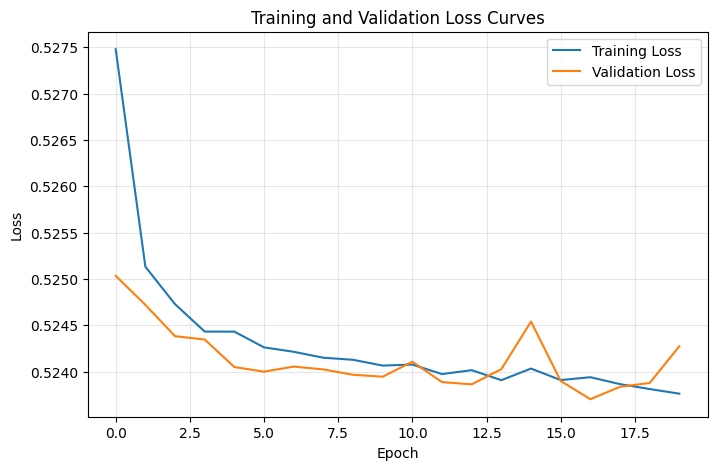

In [85]:
# Plot training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Training and Validation Loss Curves

The training and validation loss both decrease slightly during training and remain very close to each other. This suggests that the neural network is learning from the data and is not overfitting. The loss levels off after several epochs, indicating that the model has mostly finished learning.

### Evaluating on validation set

In [86]:
# Evaluate the neural network on the validation set
model.eval()

all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        logits = model(X_batch)
        # Convert logits to probabilities
        probs = torch.sigmoid(logits)
        # Convert probabilities to predictions
        preds = (probs >= 0.5).float()

        # Store results
        all_probs.extend(probs.cpu().numpy().flatten())
        all_preds.extend(preds.cpu().numpy().flatten())
        all_true.extend(y_batch.numpy().flatten())

# Calculate classification metrics
nn_results = pd.DataFrame([{
    "Model": "PyTorch Neural Network",
    "Accuracy": accuracy_score(all_true, all_preds),
    "Precision": precision_score(all_true, all_preds, zero_division=0),
    "Recall": recall_score(all_true, all_preds, zero_division=0),
    "F1": f1_score(all_true, all_preds, zero_division=0),
    "AUC-ROC": roc_auc_score(all_true, all_probs)
}])

nn_results

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,PyTorch Neural Network,0.771845,0.769227,0.999763,0.869473,0.61795


The PyTorch neural network achieved similar performance to the Scikit-learn models, with an accuracy of 0.77 and a high recall for detecting high-tip trips.

### Comparing with Scikit-learn models

In [87]:
# Compare neural network results with baseline classification models
classification_comparison_df = pd.concat(
    [classification_results_df, nn_results],
    ignore_index=True
)

classification_comparison_df

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.771680,0.769514,0.998759,0.869276,0.608686
1,Random Forest Classifier,0.764260,0.772766,0.977196,0.863040,0.590575
2,PyTorch Neural Network,0.771845,0.769227,0.999763,0.869473,0.617950


The tuned Random Forest Regressor performed slightly better than the baseline model on the validation set. It achieved lower MAE and RMSE and a higher R² score, indicating improved predictive performance after hyperparameter tuning.